<a href="https://colab.research.google.com/github/nanaKiziriya/Ankit_Jain_Lab/blob/main/DataCleaning_Kurchak1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Last edited by Nana Kiziriya on May 7, 2026
# Originally developed on Google Colab, uploaded to GitHub

#**Restart entire session before all reruns to avoid unintended consequences...*

This program accepts a spreadsheet of *[time ,variable groups ,control group]* experimental data.

It exports the data cleaned and normalized. Plot images available, too. More details below.

In [2]:
#@title **Imports**
#@markdown
import os.path
import numpy as np              # basic math
import pandas as pd             # read/write data spreadsheets
from pandas.api.types import is_list_like   # list, tuple, series, NOT string
import matplotlib.pyplot as plt # plotting
import datetime as dt

In [3]:
#@title #**0. Import Data Set + Preliminary Cleaning ⬇️**

# Terminology:
# replicate groups = variable groups + control group
# trials in (replicate) group
# DataFrame ~table (df), Series ~column (ser), dict ~label->element


#@markdown #### **[ Enter path to data file ]**
dirty_path = '/content/Kurchak_50CF4R9_50R9_ATP_THPP conc var.xlsx' #@param {type:'string'}
#@markdown >##### E.g. */content/myData.xlsx* or */home/Jane/Desktop/myData.csv*
#@markdown >##### Note: Time must be in *1st column*

#@markdown #### <br>**[ Controls are assumed to be in the last column. IF it isn't, of if there are >1 control trial, indicate so and enter a keyword only in the control label. ]**
need_ctrl_kw = True #@param {type:'boolean'}
ctrl_kw = 'blank' #@param {type:'string'}
if not need_ctrl_kw : ctrl_kw = None

#@markdown #### <br>**[ The recorded time should ideally be parsed into single numbers. Is your time data in H:M:S format? If so, it will be parsed into seconds. ]**
HMS = False #@param {type:'boolean'}

#@markdown #### <br>**[ How many datapoints to be used for trial pre-scaling? (Keep it low...) ]**
len_prescale = 3 #@param {type:'integer'}
assert(len_prescale>0)


#@markdown #### <br>**[ Do you want to Normalize between 0-1? ]**
normalize = True #@param {type:'boolean'}

In [4]:
#@title ### Export formatting


#@markdown # <br>**[ Units ]**


#@markdown ##### <br>**[ Enter TIME unit ]**
x_unit = 'Sec' #@param {type:'string'}

#@markdown ##### <br>**[ Enter ORIGINAL unit of measurement ]**
y_unit_dirty = 'Fluorescence' #@param {type:'string'}

#@markdown ##### <br>**[ Enter NORMALIZED unit ]**
y_unit_clean = 'Degree of aggregation' #@param {type:'string'}

#@markdown ##### <br>**[ What's the independent variable in your experiment? (*Not* time.) ]**
indep_var = 'Reagent concentration' #@param {type:'string'}


#@markdown # <br>**[ Program Output ]**

#@markdown ##### <br>**[ Export cleaned normalized data? ]**
exportData = True #@param {type:'boolean'}

#@markdown ##### <br>**[ Export plot images? ]**
exportImages = True #@param {type:'boolean'}

#@markdown ##### <br>**[ ... Transparent images? ]**
tpImg = True #@param {type:'boolean'}

#@markdown ##### <br>**[ Select image file extension ]**
img_ext = '.png' #@param ['.png','.jpeg','.svg','pdf'] {type:'string'}
#@markdown >##### Note: *.jpeg* does not support transparency , *.svg* is vector-based (scalable)


#@markdown ##### <br>**[ Print messages? (For debugging.) ]**
doPrint = True #@param {type:'boolean'}

In [5]:
#@title **Useful Methods**
#@markdown

cond_print = lambda *s : print(*s) if doPrint else None

def groupAvgSeries(df,name=None) :
  if isinstance(df,pd.DataFrame) :
    return pd.Series([
      np.average([
          entry
          for entry in
          df.iloc[row,:] ])
      for row in
      range(df.shape[0])
      ],name=name)
  else :
    if name : df.name=name
    return df



# PLOTTING

rainbow = ('r','orange','g','b','purple') # colors for variable groups
ctrl_color = 'gray' # color for control group

def plotPandas(x_axis,df,title:str=None,x_label:str=None,y_label:str=None,labels=None,replicates:bool=False,colors=None) :

  assert isinstance(df,pd.DataFrame) or isinstance(df,pd.Series)
  ncols = None
  if isinstance(df,pd.DataFrame) :
    ncols = df.shape[1]
    labels = df.columns if labels==None else labels if is_list_like(labels) else [labels]
  else :
    ncols = 1
    labels = [df.name]

  colors = colors if is_list_like(colors) else [colors]

  for j in range(ncols):
    plt.plot(
        x_axis,
        df.iloc[:,j] if isinstance(df,pd.DataFrame) else df,
        color = colors[j%len(colors)],
        label = (labels[0] if j==0 else None) if replicates else labels[j%len(labels)]
        )
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)



# FILE EXPORT

def _timestampPath(path) :
  dot = path.rfind('.')
  rtfn = dt.datetime.now()
  rtfn = f'_{rtfn.year}_{rtfn.month}_{rtfn.day}_{rtfn.hour}{rtfn.minute}{rtfn.second}'
  return path[:dot] + rtfn + path[dot:] if dot>-1 else path+rtfn

def _fixId(id:str) :
  return ('_' + id.strip(' _.')).replace(' ','_').replace('.','_')

def exportDataFrame(df:pd.DataFrame,id:str='ALTERED') :
  if not exportData: return

  dot = dirty_path.rfind('.')
  clean_path = dirty_path[:dot] + _fixId(id) + dirty_path[dot:]

  cleaner_path = _timestampPath(clean_path)
  while os.path.isfile(cleaner_path) :
    cleaner_path = _timestampPath(clean_path)

  try:
    df.to_excel(cleaner_path,index=False)
  except:
    print('Something went wrong while exporting',id,'data.')

def exportPlot(id='PLOTLY') :
  if not exportImages: return

  dot = dirty_path.rfind('.')
  clean_path = dirty_path[:dot] + _fixId(id) + img_ext

  cleaner_path = _timestampPath(clean_path)
  while os.path.isfile(cleaner_path) :
    cleaner_path = _timestampPath(clean_path)

  try:
    plt.savefig(cleaner_path, transparent=tpImg)
  except:
    print(f'Something went wrong while exporting',id,'plot image.')




In [6]:
#@title ### Convert to dataframe

# Convert file to pandas dataframe
df_dirty = pd.read_excel(dirty_path)

assert(df_dirty.shape[1]>2) # need 1 time column, at least 1 control, and at least 1 trial

cond_print('Before dropping bottom NaN rows:\n', df_dirty)

Before dropping bottom NaN rows:
           Time    5 mM  Unnamed: 2  Unnamed: 3    3 mM  Unnamed: 5  \
0     0.003056   460.0       446.0       422.0   435.0       401.0   
1     0.069722   432.0       442.0       414.0   410.0       386.0   
2     0.136389   444.0       446.0       403.0   418.0       386.0   
3     0.203056   433.0       435.0       410.0   409.0       391.0   
4     0.269722   423.0       451.0       398.0   417.0       364.0   
..         ...     ...         ...         ...     ...         ...   
176  11.736390  2733.0      3506.0      3124.0  2197.0      3092.0   
177  11.803060  2776.0      3539.0      3116.0  2210.0      3114.0   
178  11.869720  2771.0      3519.0      3084.0  2247.0      3079.0   
179  11.936390  2810.0      3571.0      3134.0  2228.0      3124.0   
180  12.003060     NaN         NaN         NaN     NaN         NaN   

     Unnamed: 6    2 mM  Unnamed: 8  Unnamed: 9   1 mM  Unnamed: 11  \
0         462.0   448.0       427.0       446.0  409.0

In [7]:
#@title ### Drop NaN row
while 'NaN' in str(df_dirty.iloc[df_dirty.shape[0]-1,:]) :
  df_dirty.drop(df_dirty.shape[0]-1, inplace=True)
cond_print('After dropping bottom NaN rows:\n', df_dirty)

After dropping bottom NaN rows:
           Time    5 mM  Unnamed: 2  Unnamed: 3    3 mM  Unnamed: 5  \
0     0.003056   460.0       446.0       422.0   435.0       401.0   
1     0.069722   432.0       442.0       414.0   410.0       386.0   
2     0.136389   444.0       446.0       403.0   418.0       386.0   
3     0.203056   433.0       435.0       410.0   409.0       391.0   
4     0.269722   423.0       451.0       398.0   417.0       364.0   
..         ...     ...         ...         ...     ...         ...   
175  11.669720  2745.0      3520.0      3078.0  2214.0      3039.0   
176  11.736390  2733.0      3506.0      3124.0  2197.0      3092.0   
177  11.803060  2776.0      3539.0      3116.0  2210.0      3114.0   
178  11.869720  2771.0      3519.0      3084.0  2247.0      3079.0   
179  11.936390  2810.0      3571.0      3134.0  2228.0      3124.0   

     Unnamed: 6    2 mM  Unnamed: 8  Unnamed: 9   1 mM  Unnamed: 11  \
0         462.0   448.0       427.0       446.0  409.0 

In [8]:
#@title ### Separate the time column

# BEFORE: df_dirty
# AFTER:  ser_time | df_trials(no times)

ser_time = df_dirty.pop(df_dirty.columns[0])
assert(ser_time.name not in df_dirty.columns)

if HMS :
  temp = list()
  for i in range(len(ser_time)) :
    t = dt.datetime.strptime(str(ser_time[i]), "%H:%M:%S")
    temp.append(t.hour*3600+t.minute*60+t.second)
  ser_time = pd.Series(temp)

cond_print(ser_time)
df_trials = df_dirty; del df_dirty # renaming

0       0.003056
1       0.069722
2       0.136389
3       0.203056
4       0.269722
         ...    
175    11.669720
176    11.736390
177    11.803060
178    11.869720
179    11.936390
Name: Time, Length: 180, dtype: float64


In [9]:
#@title ### Fix column naming for replicate trials, and separate the replicate groups
# PURPOSE: If spreadsheet has merged column headings to represent replicate groups, pd.DataFrame uses label for 1st column in group, and names other group members 'Unnamed:NUM'

# BEFORE: ser_time | df_trials
# AFTER:  ser_time | dict_groups_df(df_trials sep. by group)

target = 'Unnamed'

dict_groups_df = dict() # {group_N_label : df_group_N}

if target in str(df_trials.columns) and not all(target in col for col in df_trials.columns):
  cond_print(f'Before rename:\n{df_trials.columns}\n')

  trial_relabels = dict() # {old_label : new_label}
  group_splits = [] # [num_trials_grp1, num_trials_grp2, ...]
  group_labels = [] # ['grp1', 'grp2', ...]
  group_label = target
  trial_count = 0

  for trial_label in df_trials.columns :

    if target not in trial_label : # if column is named (i.e. new group)...

      if trial_count>0 : # store previous group info if nonempty...
        group_splits.append(trial_count)
        group_labels.append(group_label)

      group_label = trial_label # update group label (dict_key)
      trial_count = 0 # reset trial count

    trial_count+=1
    trial_relabels.update({trial_label:f'{group_label} [v.{trial_count}]'})

  # Store last group
  group_splits.append(trial_count)
  group_labels.append(group_label)

  df_trials.rename(columns=trial_relabels, inplace=True) # relabel columns

  if not need_ctrl_kw : ctrl_kw = group_label

  print(group_splits)
  print(group_labels)
  # print(trial_relabels)
  print(df_trials.columns)

  del group_label, trial_count, trial_relabels

  assert(sum(group_splits)==len(df_trials.columns)) # num_columns preserved
  assert(len(group_splits)==len(group_labels)) # num_groups preserved

  cond_print(f'After rename:\n{df_trials.columns}\n')

  # Splitting:
  for i in range(len(group_splits)) : # for group i ...
    dict_groups_df.update({
        group_labels[i] : # match label i ...
        pd.concat([       # to group of trials (popped off df_trials)
            df_trials.pop(
                df_trials.columns[0]) # trials in ...
            for j in
            range(group_splits[i])    # the first j columns
            ], axis=1)
        })

    assert(g in l for g in group_labels for l in dict_groups_df[g])

else :
  cond_print(f'Nothing to relabel: {df_trials.columns}')
  for col in df_trials.columns :
    dict_groups_df.update({col : df_trials.pop(col) })

assert(df_trials.shape[1]==0)
del df_trials

cond_print(f'After split:')
for group in dict_groups_df.values() :
  cond_print(group,'\n')
del group

Before rename:
Index(['5 mM', 'Unnamed: 2', 'Unnamed: 3', '3 mM', 'Unnamed: 5', 'Unnamed: 6',
       '2 mM', 'Unnamed: 8', 'Unnamed: 9', '1 mM', 'Unnamed: 11',
       'Unnamed: 12', '0.5 mM', 'Unnamed: 14', 'Unnamed: 15', 'Nile Red blank',
       'Unnamed: 17', 'Unnamed: 18'],
      dtype='object')

[3, 3, 3, 3, 3, 3]
['5\xa0mM', '3\xa0mM', '2\xa0mM', '1\xa0mM', '0.5\xa0mM', 'Nile Red blank']
Index(['5 mM [v.1]', '5 mM [v.2]', '5 mM [v.3]', '3 mM [v.1]', '3 mM [v.2]',
       '3 mM [v.3]', '2 mM [v.1]', '2 mM [v.2]', '2 mM [v.3]', '1 mM [v.1]',
       '1 mM [v.2]', '1 mM [v.3]', '0.5 mM [v.1]', '0.5 mM [v.2]',
       '0.5 mM [v.3]', 'Nile Red blank [v.1]', 'Nile Red blank [v.2]',
       'Nile Red blank [v.3]'],
      dtype='object')
After rename:
Index(['5 mM [v.1]', '5 mM [v.2]', '5 mM [v.3]', '3 mM [v.1]', '3 mM [v.2]',
       '3 mM [v.3]', '2 mM [v.1]', '2 mM [v.2]', '2 mM [v.3]', '1 mM [v.1]',
       '1 mM [v.2]', '1 mM [v.3]', '0.5 mM [v.1]', '0.5 mM [v.2]',
       '0.5 mM [v.3]', 

In [10]:
#@title ### Separate the control group

# BEFORE: ser_time | dict_groups_df
# AFTER:  ser_time | dict_vgroups_df(variable groups only, no ctrls) | df_ctrls

df_ctrls = None

if need_ctrl_kw :
  ctrl_kw = tuple(filter((lambda _:ctrl_kw.upper() in _.upper()), dict_groups_df.keys())) # use keyword to grab entire control group label

  assert len(ctrl_kw)==1, f'only 1 group should be the control group: {ctrl_kw}'
  ctrl_kw = ctrl_kw[0]

df_ctrls = dict_groups_df.pop(ctrl_kw)

cond_print(f'CONTROLS:\n{df_ctrls}')

dict_vgroups_df = dict_groups_df; del dict_groups_df

CONTROLS:
     Nile Red blank [v.1]  Nile Red blank [v.2]  Nile Red blank [v.3]
0                    42.0                  46.0                  78.0
1                    43.0                  46.0                  88.0
2                    41.0                  42.0                  93.0
3                    38.0                  40.0                  89.0
4                    43.0                  50.0                  92.0
..                    ...                   ...                   ...
175                  44.0                  54.0                  90.0
176                  45.0                  51.0                  78.0
177                  44.0                  50.0                  82.0
178                  44.0                  48.0                  88.0
179                  45.0                  50.0                  90.0

[180 rows x 3 columns]


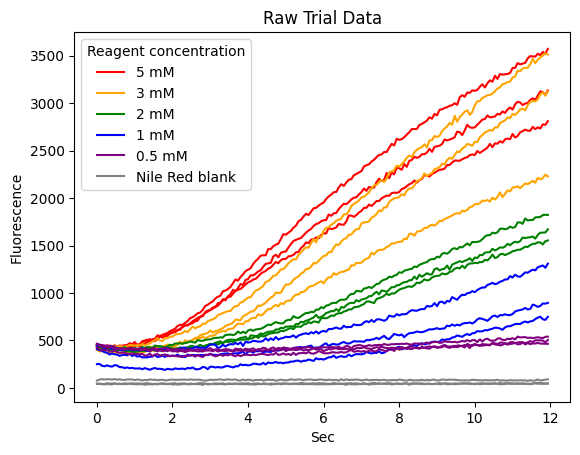

In [11]:
#@title ### **INITIAL VISUALIZATION:**

if len(dict_vgroups_df.keys()) > len(rainbow) :
  rainbow = ('r','orange','peru','goldenrod','yellowgreen','mediumspringgreen','g','turquoise','b','slateblue','darkslateblue','rebeccapurple','darkorchid','purple','mediumvioletred','indianred','deepink','pink')

for k, group in enumerate(dict_vgroups_df):
  plotPandas(
      ser_time,
      dict_vgroups_df[group],
      labels=group,
      colors=rainbow[k%len(rainbow)],
      replicates=True)

plotPandas(
    ser_time,
    df_ctrls,
    title='Raw Trial Data',
    x_label=x_unit,
    y_label=y_unit_dirty,
    labels=ctrl_kw,
    colors=ctrl_color,
    replicates=True)

plt.legend(title=indep_var)
exportPlot('DIRTYPLOT')
plt.show()

In [12]:
#@title #**1. Averaging Control Trials**
ser_ctrl = None
if isinstance(df_ctrls,pd.DataFrame) :
  cond_print(f'Before averaging:\n',df_ctrls)

  ser_ctrl = groupAvgSeries(df_ctrls,name=ctrl_kw)
  assert(len(ser_ctrl)==df_ctrls.shape[0])
  cond_print(f'After averaging:\n',ser_ctrl)
  del df_ctrls
else :
  ser_ctrl = df_ctrls
# Now we have: ser_time | dict_vgroups_df | ser_ctrl

Before averaging:
      Nile Red blank [v.1]  Nile Red blank [v.2]  Nile Red blank [v.3]
0                    42.0                  46.0                  78.0
1                    43.0                  46.0                  88.0
2                    41.0                  42.0                  93.0
3                    38.0                  40.0                  89.0
4                    43.0                  50.0                  92.0
..                    ...                   ...                   ...
175                  44.0                  54.0                  90.0
176                  45.0                  51.0                  78.0
177                  44.0                  50.0                  82.0
178                  44.0                  48.0                  88.0
179                  45.0                  50.0                  90.0

[180 rows x 3 columns]
After averaging:
 0      55.333333
1      59.000000
2      58.666667
3      55.666667
4      61.666667
         ...  

In [13]:
#@title #**2. Subtract Control Baseline From All Other Trials**

cond_print(f'Before baselining:\n{dict_vgroups_df}\n')

for group in dict_vgroups_df :
  dict_vgroups_df[group] = dict_vgroups_df[group].sub(ser_ctrl, axis=0)

cond_print(f'After baselining:\n{dict_vgroups_df}\n')

bad_groups = list()

for k,v in dict_vgroups_df.items() :
  if not v.abs().equals(v) : bad_groups.append(k)

for v in bad_groups :
  dict_vgroups_df.pop(v)
  print(f'Group {v} was removed for having negative values. Was too close to baseline for this normalization procedure.')

Before baselining:
{'5\xa0mM':      5 mM [v.1]  5 mM [v.2]  5 mM [v.3]
0         460.0       446.0       422.0
1         432.0       442.0       414.0
2         444.0       446.0       403.0
3         433.0       435.0       410.0
4         423.0       451.0       398.0
..          ...         ...         ...
175      2745.0      3520.0      3078.0
176      2733.0      3506.0      3124.0
177      2776.0      3539.0      3116.0
178      2771.0      3519.0      3084.0
179      2810.0      3571.0      3134.0

[180 rows x 3 columns], '3\xa0mM':      3 mM [v.1]  3 mM [v.2]  3 mM [v.3]
0         435.0       401.0       462.0
1         410.0       386.0       439.0
2         418.0       386.0       442.0
3         409.0       391.0       422.0
4         417.0       364.0       430.0
..          ...         ...         ...
175      2214.0      3039.0      3458.0
176      2197.0      3092.0      3481.0
177      2210.0      3114.0      3501.0
178      2247.0      3079.0      3526.0
179      2228

In [14]:
#@title #**3. Prescale trials within each group**
# Within in each replicate group, make sure the average of the first few data points match up for each trial
# scale UP to avoid precision loss from truncation

# make sure scaling up does not create overflow error
# to be safe, largest value to power of len_prescale should not overflow
import sys
MAX = pd.concat(dict_vgroups_df.values()).abs().max()
try :
  MAX = max(MAX.abs())
except :
  cond_print(f'oops {MAX} is already the max :)')
assert(MAX < np.power(sys.float_info.max, (1/len_prescale)))
# IF IT CREATES OVERFLOW, THE FOLLOWING ALGORITHM HAS TO BE REPROGRAMMED. I AM NOT DOING ALL THAT RIGHT NOW.



for group,df in dict_vgroups_df.items() :
  if isinstance(df,pd.DataFrame) :
    prescale_avgs = list(map(
        lambda i :
            np.average([
            pre
            for pre in
            df.iloc[0:len_prescale,i] ]),
        range(df.shape[1])
        ))
    total_prod = np.prod(prescale_avgs)
    prescale_factors = list(map(lambda _:total_prod/_,prescale_avgs))

    # multiply each column j by prescale_factors[j] all at once using df.mul
    assert(len(prescale_factors)==(df.shape[1]))
    dict_vgroups_df[group] = df.mul(prescale_factors, axis=1)
  else :
    dict_vgroups_df[group] = df
# for row in
# range(df_ctrls.shape[0])

cond_print(f'After prescaling:\n',dict_vgroups_df)
# starting values in each column should be approximately the same
# if they're very different, consider lowering len_prescale OR using a different algorithm to prescale (would have to be hardcoded :P)
# Note: prescaling is to balance statistical weight of each trial before averaging them


After prescaling:
 {'5\xa0mM':       5 mM [v.1]    5 mM [v.2]   5 mM [v.3]
0     55647332.0  5.381468e+07   55009900.0
1     51292722.0  5.275859e+07   53259585.0
2     52988728.0  5.335551e+07   51659297.0
3     51888616.0  5.225350e+07   53159567.0
4     49688392.0  5.363101e+07   50459081.0
..           ...           ...          ...
175  368858386.0  4.762507e+08  452381414.0
176  367849950.0  4.749651e+08  459982782.0
177  373671376.0  4.794190e+08  458682548.0
178  372800454.0  4.764803e+08  453681648.0
179  377934310.0  4.834138e+08  460932953.0

[180 rows x 3 columns], '3\xa0mM':        3 mM [v.1]    3 mM [v.2]    3 mM [v.3]
0    4.935667e+07  4.898097e+07  4.925185e+07
1    4.563000e+07  4.633590e+07  4.602222e+07
2    4.671333e+07  4.638313e+07  4.642593e+07
3    4.593333e+07  4.751673e+07  4.436704e+07
4    4.619333e+07  4.284063e+07  4.460926e+07
..            ...           ...           ...
175  2.796733e+08  4.217464e+08  4.112126e+08
176  2.780700e+08  4.299178e+08  4.14

In [15]:
#@title #**4. Average trials in each group, then scale-equalize groups**
# After averaging each group into a series, scale each group to start at 1
# Then put all group columns into a single dataframe

df_vgroups = pd.concat((groupAvgSeries(df,name=group) for group,df in dict_vgroups_df.items()), axis=1)

df_vgroups = df_vgroups.div(df_vgroups.iloc[0,:],axis=1)

cond_print(df_vgroups)

         5 mM      3 mM      2 mM      1 mM    0.5 mM
0    1.000000  1.000000  1.000000  1.000000  1.000000
1    0.956461  0.934945  0.962962  0.995130  0.953887
2    0.960672  0.945341  0.938758  0.942558  0.930214
3    0.956405  0.933787  0.934092  0.903992  0.939724
4    0.934983  0.905506  0.904930  0.923294  0.915970
..        ...       ...       ...       ...       ...
175  7.888827  7.538697  4.119214  2.943957  1.115830
176  7.921096  7.605902  4.152533  2.993100  1.117803
177  7.975665  7.653112  4.151728  2.978886  1.111171
178  7.922097  7.669065  4.179992  2.940023  1.101756
179  8.039555  7.680430  4.211691  3.033292  1.118523

[180 rows x 5 columns]


In [16]:
#@title #**5. Normalize entire set of values: Scale onto [0,1]**
# max value in df_vgroups should =1

if normalize :
  df_vgroups = df_vgroups.div( df_vgroups.max().max() )

  assert(1==df_vgroups.max().max())

df_vgroups

,5 mM,3 mM,2 mM,1 mM,0.5 mM
0,0.124385,0.124385,0.124385,0.124385,0.124385
1,0.118969,0.116293,0.119778,0.123779,0.118649
2,0.119493,0.117586,0.116767,0.117240,0.115705
3,0.118962,0.116149,0.116187,0.112443,0.116888
4,0.116298,0.112631,0.112560,0.114844,0.113933
...,...,...,...,...,...
175,0.981252,0.937701,0.512368,0.366184,0.138793
176,0.985265,0.946060,0.516513,0.372297,0.139038
177,0.992053,0.951932,0.516413,0.370529,0.138213
178,0.985390,0.953917,0.519928,0.365695,0.137042


#**In Conclusion...**

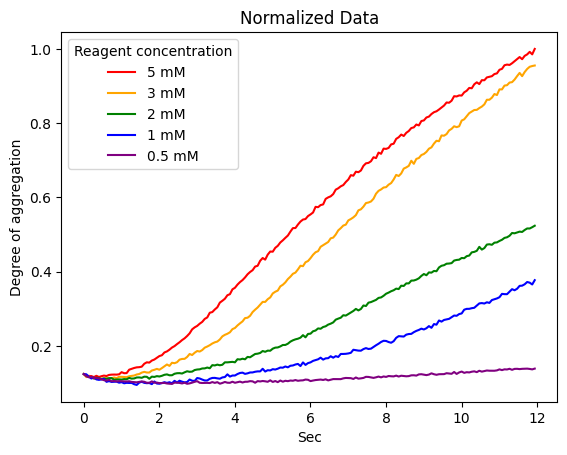

In [17]:
#@title ### **FINAL VISUALIZATION:**

plotPandas(
    ser_time,
    df_vgroups,
    title='Normalized Data',
    x_label=x_unit,
    y_label=y_unit_clean,
    colors=rainbow)

plt.legend(title=indep_var)

exportPlot(id='CLEANPLOT')
plt.show()

In [18]:
#@title ###Reinsert time column and export file

# Reinsert time column
df_vgroups.insert(0,ser_time.name,ser_time)

# Exporting
exportDataFrame(df_vgroups, id=f'CLEANDATA_n01ps{len_prescale}')

#***FILE(S) EXPORTED AND READY TO FIT TO YOUR FAVORITE DATA MODEL! :D***